# Similarity processing using text embedder

Here I try and use a text embedder to build to compare the semantic content of sentences that are used in validated questionnaire to measure a particular mode of pain worry often called catastrophising.

I implement a natural language processing pipeline for analyzing catastrophizing language patterns in text. The approach uses one large embedding model combined with different dimensionality reduction techniques.

## Aim:

* Discover latent semantic dimensions within pain catastrophizing statements
* Identify representative statements for each latent semantic dimension
* Explore the application of these semantic dimensions quantify the semantic distance between the explicit content a sentence and identified latent semantic clusters

## Data Flow Architecture

Embedding Generation → Dimensionality Reduction → HDBSCAN Clustering

**Embedding Generation:**
Her I try and use the BAAI/bge-large-en-v1.5 model to create high-dimensional (1024D) embeddings. This model is specifically optimized for semantic similarity tasks. Reference embeddings include both catastrophizing statements (50 items from validated questionnaires) and non-catastrophizing text. This new dataset includes:

1. Catastrophizing references: Statements from validated pain catastrophizing questionnaires
2. Non-catastrophizing statements: Control statements including neutral pain descriptions and everyday language

**Embedding processing**

Normalizes embeddings (L2 normalization) to optimize for cosine similarity
Combined label approach separates catastrophizing (1) from non-catastrophizing (0) statements

**Dimensionality Reduction**

I used supervised UMAP for dimensionality reduction with these parameters:
* n_components=5: Reduces to 5 dimensions
* n_neighbors=15: Balances local and global structure
* min_dist=0.1: Controls compactness of embedding
* metric='cosine': Appropriate for semantic text embeddings
* target_metric='categorical': Incorporates binary labels

**HDBSCAN Clustering**
HDBSCAN is applied to UMAP-reduced embeddings to identify natural groupings withing the catastrophizing group based on hierarchical density patterns



In [1]:
#https://pmc.ncbi.nlm.nih.gov/articles/PMC7060750/
catastrophizing_references = [
	"When I become aware of my pain, this thought comes through my head: 'I can't have a tumour, can I?'",
	"When I become aware of my pain, this thought comes through my head: 'I wonder if I have the same serious illness as..'",
	"When I become aware of my pain, this thought comes through my head: 'it isn't a serious illness, is it?'",
	"When I feel pain I feel like I just want to get up and run away",
	"When I feel pain I begin thinking of all the possible bad things that could go wrong in association with the pain",
	"When I feel pain I find myself worrying about possibly dying",
	"When I feel pain I find myself expecting the worst",
	"When I feel pain I tend to think that my pain is pretty awful",
	"When I feel pain I can't help but concentrate on how bad the pain actually feels",
	"When I feel pain I find it virtually impossible to keep my mind off of my pain and how bad it hurts",
	"When I feel pain I begin to worry that something might be seriously wrong with me",
	"When I feel pain, I feel my life isn't worth living",
	"When I'm in pain, I worry all the time about whether the pain will end",
	"When I'm in pain, I feel I can't go on",
	"When I'm in pain, it's terrible and I think it's never going to get any better",
	"When I'm in pain, it's awful and I feel that it overwhelms me",
	"When I'm in pain, I feel I can't stand it anymore",
	"When I'm in pain, I become afraid that the pain will get worse",
	"When I'm in pain, I keep thinking of other painful events",
	"When I'm in pain, I anxiously want the pain to go away",
	"When I'm in pain, I can't seem to keep it out of my mind",
	"When I'm in pain, I keep thinking about how much it hurts",
	"When I'm in pain, I keep thinking about how badly I want the pain to stop",
	"When I'm in pain, there's nothing I can do to reduce the intensity of the pain",
	"When I'm in pain, I wonder whether something serious may happen",
	"I often think back to the days when I had no pain",
	"I focus on the pain all the time",
	"Because of the pain I consider myself an unlucky person",
	"Because of the pain I think that fate has caught up with me",
	"Because of the pain The word pain frightens me",
	"Because of the pain I often think: 'Why is this happening to me?'",
	"I think that, because of the pain, I have changed my view of life",
	"I feel powerless against the pain",
	"Because of the pain I think I am always very tense",
	"Because of the pain I make sure I protect myself from extra pain",
	"Because of the pain I have become less able mentally",
	"Because of the pain I consider myself to be a hopeless case",
	"When the pain is very strong I get furious",
	"I sometimes wonder how other people cope with severe pain",
	"I cannot live without pain-killers",
	"I am disappointed in myself for giving in to the pain",
	"I cannot stand this pain any longer",
	"No matter what I do, my pain doesn't change anyway",
	"I need to take some pain medication",
	"Havin pain will never end",
	"Because of the pain I am a hopeless case",
	"When will the pain get worse again?",
	"This pain is killing me",
	"Because of the pain I can't go on anymore",
	"This pain drives me crazy",    
]

In [2]:
neutral_pain_statements = [
    "I feel some pain today but I can manage it.",
    "My back hurts a bit after sitting for too long.",
    "I need to take my prescribed medication for this pain.",
    "The pain comes and goes throughout the day.",
    "I notice the pain increases when I'm tired.",
    "My shoulder feels stiff in the morning.",
    "I experience discomfort when walking upstairs.",
    "The pain is noticeable but not overwhelming.",
    "My joints ache slightly when it rains.",
    "I feel a dull ache in my lower back.",
    "The doctor says this pain is temporary.",
    "My pain level is about a 3 out of 10 today.",
    "I need to rest when my knee starts hurting.",
    "My pain tends to be worse in the evening.",
    "I've been experiencing this pain for a few days now.",
    "Physical therapy helps reduce my pain.",
    "I'm aware of the pain but can focus on other things.",
    "My medication takes the edge off the pain.",
    "The pain is annoying but I can function with it.",
    "I need to be careful not to aggravate my pain."
]
positive_pain_statements = [
    "When I'm in pain, I practice deep breathing exercises.",
    "I find that gentle stretching helps with my pain.",
    "I can manage this pain by pacing my activities.",
    "Despite the pain, I can still enjoy many aspects of life.",
    "I've learned several strategies to cope with my pain.",
    "My pain management plan is working better lately.",
    "I feel empowered when I successfully manage my pain.",
    "I know this flare-up will pass like previous ones.",
    "The pain is there, but it doesn't define me.",
    "I'm getting better at recognizing when to rest.",
    "Each day with less pain is a victory worth celebrating.",
    "I'm grateful for the activities I can still do despite pain.",
    "I've become more mindful about my body's signals.",
    "Pain has taught me to appreciate pain-free moments more.",
    "I'm learning which exercises help rather than hurt."
]
general_statements = [
    "I need to go grocery shopping this afternoon.",
    "The weather forecast says it will rain tomorrow.",
    "I'm meeting my friend for coffee at 2pm.",
    "My favorite show has a new episode tonight.",
    "I should call my parents this weekend.",
    "The garden needs watering today.",
    "I finished reading that book yesterday.",
    "The traffic was heavy on my way to work.",
    "I'm planning a trip to the mountains next month.",
    "My dog needs to go for a walk soon.",
    "The internet connection seems slow today.",
    "I need to pay my electricity bill.",
    "The neighbors are having a party this weekend.",
    "I'm thinking about repainting the kitchen.",
    "The car needs an oil change soon.",
    "I'm learning to play the guitar in my free time.",
    "We're having chicken for dinner tonight.",
    "I need to clean out the refrigerator.",
    "The movie we watched last night was interesting.",
    "I'm considering changing my phone plan.",
    "The flowers in the garden are blooming beautifully.",
    "I need to buy a birthday present for my nephew.",
    "The airline ticket prices have gone up recently.",
    "I should organize my desk this weekend.",
    "The library book is due back on Friday."
]
non_catastrophizing_statements = neutral_pain_statements + positive_pain_statements + general_statements



## STEP1:  Get embeddings

Here we converts our 50 catoastrophizing sentences into a high dimensional space of numberic vectors using a SentenceTransformer (in this case [bge-large-en-v1.5](https://huggingface.co/BAAI/bge-large-en-v1.5))

In [3]:
from sentence_transformers import SentenceTransformer
#from sklearn.cluster import AgglomerativeClustering
#from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize

import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage


#model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
#model = SentenceTransformer('sentence-transformers/all-mpnet-base-v2')
model = SentenceTransformer('BAAI/bge-large-en-v1.5')


combined_texts = catastrophizing_references + non_catastrophizing_statements
combined_labels = [1]*len(catastrophizing_references) + [0]*len(non_catastrophizing_statements)


ref_embeddings= model.encode(combined_texts)
# BGE models require L2 normalization before cosine similarity
ref_normalized_embeddings = normalize(ref_embeddings, norm='l2')




2025-04-30 11:49:40.901628: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-04-30 11:49:40.901667: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-04-30 11:49:40.903047: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-30 11:49:40.910934: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-04-30 11:49:42.050442: W tensorflow/compiler/tf2

In [4]:
ref_normalized_embeddings.shape

(110, 1024)

## STEP2: reduce embedding dimensionality
Use non-catastrophizing statements to train the compressor in detecting relevant diffences between embeddings:

1. compress to distinguish catastrophizing from normal language
2. compress catastrophizing statements to identify subtypes

### step2.1: distinguish catastrophizing from normal language

Text(0, 0.5, 'UMAP Dimension 2')

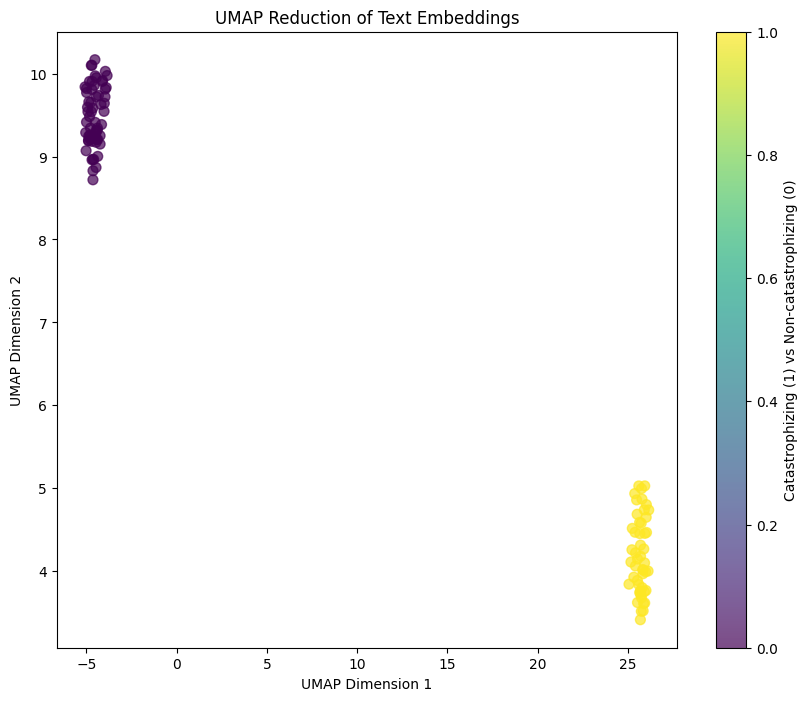

In [5]:
# dimensionality reduction with UMAP
import umap.umap_ as umap
import umap.plot

reducer = umap.UMAP(
    # https://umap-learn.readthedocs.io/en/latest/parameters.html
    n_components=5,        # Target dimensionality
    n_neighbors=15,         # Local neighborhood size
    min_dist=0.1,           # Minimum distance between points
    metric='cosine',        # Distance metric for semantic embeddings
    target_metric='categorical'  # Incorporate label information
    )

ref_embeddings_reduced = reducer.fit_transform(ref_normalized_embeddings, y=combined_labels)

# Create 2D visualization of the first two dimensions
plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    ref_embeddings_reduced[:, 0], 
    ref_embeddings_reduced[:, 1],
    c=combined_labels,
    cmap='viridis',
    alpha=0.7,
    s=50
)
plt.colorbar(scatter, label='Catastrophizing (1) vs Non-catastrophizing (0)')
plt.title('UMAP Reduction of Text Embeddings')
plt.xlabel('UMAP Dimension 1')
plt.ylabel('UMAP Dimension 2')


## Distinguish catastrophizing subtypes with HDBSCAN

HDBSCAN is a density based (hierarchical) clustering algorithm. Clustering algorithms are generally thought of as an unsupervised machine learning method in the sense that you can get something out of your data without a target or even a clear question. The idea is intuitive i.e. finding similarities in N dimensional vector spaces.

https://link.springer.com/chapter/10.1007/978-3-642-37456-2_14

https://joss.theoj.org/papers/10.21105/joss.00205

https://hdbscan.readthedocs.io/en/latest/parameter_selection.html



In [13]:
catastrophizing_indices = [i for i, label in enumerate(combined_labels) if label == 1]
catastrophizing_embeddings = ref_normalized_embeddings[catastrophizing_indices]
catastrophizing_texts = [combined_texts[i] for i in catastrophizing_indices]

# We apply umap to original normalised embeddings to gather a 2D space for plotting the HDBscanned clusters
subtype_reducer = umap.UMAP(
    n_components=10,       # down to 10 dimensions from 1024
    n_neighbors=10,        # More local focus to find subtypes
    min_dist=0.05,         # Tighter clusters
    metric='cosine',       # Semantic similarity
    random_state=42        # For reproducibility
)

# We apply umap to original normalised embeddings to gather a 2D space for plotting the HDBscanned clusters
Visualisation_reducer = umap.UMAP(
    n_components=2,        # 2D for visualization
    n_neighbors=10,        # More local focus to find subtypes
    min_dist=0.05,         # Tighter clusters
    metric='cosine',       # Semantic similarity
    random_state=42        # For reproducibility
)
viz_embeddings = Visualisation_reducer.fit_transform(catastrophizing_embeddings)

subtype_embeddings = subtype_reducer.fit_transform(catastrophizing_embeddings)


/home/diego/CRIISP-WP6/venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/diego/CRIISP-WP6/venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [12]:
subtype_embeddings.shape

(50, 10)

In [16]:
from sklearn.cluster import HDBSCAN

clusterer = HDBSCAN(
    min_cluster_size=3,
    min_samples=2,
    cluster_selection_epsilon=0.5,
    metric='euclidean'
)

cluster_labels = clusterer.fit_predict(subtype_embeddings)
v_cluster_labels = clusterer.fit_predict(viz_embeddings) # this will be used later for visualisation

# Analyze cluster contents
from collections import Counter
import pandas as pd

# Create dataframe of results
results_df = pd.DataFrame({
    'text': catastrophizing_texts,
    'cluster': cluster_labels
})

# Print common terms in each cluster
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np

def analyze_clusters(texts, clusters):
    cluster_ids = np.unique(clusters)
    cluster_ids = cluster_ids[cluster_ids >= 0]  # Remove noise points (-1)

    for cluster_id in cluster_ids:
        print(f"\n== CLUSTER {cluster_id} ==")
        cluster_texts = [texts[i] for i, c in enumerate(clusters) if c == cluster_id]

        # Find central statement (most representative)
        if len(cluster_texts) > 1:
            # Embed all texts in the cluster
            embeddings = model.encode(cluster_texts)
            norm_embeddings = normalize(embeddings, norm='l2')

            # Compute similarity matrix
            sim_matrix = cosine_similarity(norm_embeddings)

            # Find text with highest average similarity to all others
            avg_sim = np.mean(sim_matrix, axis=1)
            central_idx = np.argmax(avg_sim)

            print(f"\nCENTRAL STATEMENT: {cluster_texts[central_idx]}")

        # Print cluster statements
        print(f"\nN. of Items ({len(cluster_texts)}):")
        for text in cluster_texts:
            print(f"- {text}")

        # Find key terms
        vectorizer = CountVectorizer(stop_words='english')
        X = vectorizer.fit_transform(cluster_texts)
        words = vectorizer.get_feature_names_out()

        # Sum word frequencies across docs
        word_sum = X.sum(axis=0)
        word_freq = [(word, word_sum[0, idx]) for idx, word in enumerate(words)]
        word_freq.sort(key=lambda x: x[1], reverse=True)
        # Print top terms
        
        print("\nMost repeated terms:", ", ".join([w for w, f in word_freq[:10]]))

        print(f"Total statements: {len(cluster_texts)}")

analyze_clusters(catastrophizing_texts, cluster_labels)


== CLUSTER 0 ==

CENTRAL STATEMENT: Because of the pain I consider myself to be a hopeless case

N. of Items (9):
- Because of the pain I consider myself an unlucky person
- Because of the pain I think that fate has caught up with me
- I think that, because of the pain, I have changed my view of life
- I feel powerless against the pain
- Because of the pain I have become less able mentally
- Because of the pain I consider myself to be a hopeless case
- I am disappointed in myself for giving in to the pain
- Because of the pain I am a hopeless case
- Because of the pain I can't go on anymore

Most repeated terms: pain, case, consider, hopeless, think, able, anymore, caught, changed, disappointed
Total statements: 9

== CLUSTER 1 ==

CENTRAL STATEMENT: When I'm in pain, I feel I can't stand it anymore

N. of Items (6):
- When I feel pain I feel like I just want to get up and run away
- When I feel pain, I feel my life isn't worth living
- When I'm in pain, I feel I can't go on
- When I'

Text(0, 0.5, 'UMAP Dimension 2')

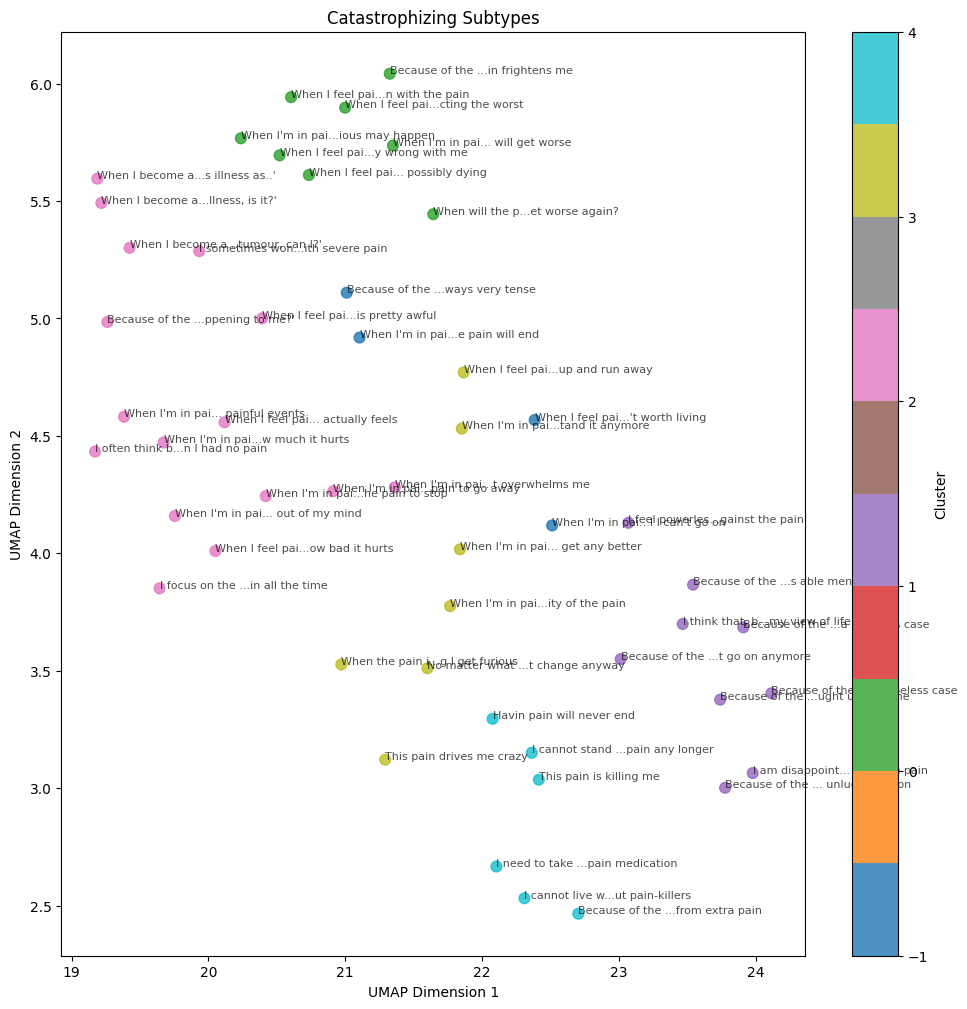

In [18]:
# Visualize subtypes
plt.figure(figsize=(12, 12))
scatter = plt.scatter(
    viz_embeddings[:, 0],
    viz_embeddings[:, 1],
    c=v_cluster_labels,
    cmap='tab10',
    alpha=0.8,
    s=60
)
# Add labels for points
for i, txt in enumerate(catastrophizing_texts):
    # Shorten text for readability
    short_txt = txt[:15] + "..." + txt[-15:] if len(txt) > 30 else txt
    plt.annotate(short_txt, (viz_embeddings[i, 0], viz_embeddings[i, 1]), 
                fontsize=8, alpha=0.7)

plt.colorbar(scatter, label='Cluster')
plt.title('Catastrophizing Subtypes')
plt.xlabel('UMAP Dimension 1')
plt.ylabel('UMAP Dimension 2')